# E-shop clothing 2008: Next category prediction

## 1. Project overview

This project predicts the next product category a user will click in the same session. A session is a group of clicks from one browsing visit.

The target is what we want to predict. Here, the target is the category of the next click:
- Trousers
- Skirts
- Blouses
- Sale

We want to find out whether earlier clicks help us predict the next category better.

A feature is a piece of information used to make a prediction. We will compare two groups of features:

1. Current Only: information from the current click.
2. Current + Historical Behavior: information from the current click and earlier clicks in the same session.

**Evaluation terms**

We will use these measures to compare the models:
- Accuracy: the share of predictions that are correct.
- F1: a score that balances how often a category prediction is correct and how many actual clicks in that category the model finds.
- Macro F1: the average F1 score across the four categories. Each category has equal weight. This is our main measure.
- Weighted F1: the average F1 score with more weight given to categories that have more examples.
- Confusion matrix: a table that compares the true categories with the predicted categories.

No models have been trained yet, so we cannot say which feature group works better.

### 1.1 Research question

Do earlier clicks in a session help us predict the next category better than the current click alone?

## 2. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

## 3. Load dataset

In [2]:
df = pd.read_csv("e-shop clothing 2008.csv")

df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


The first rows share session ID 1 but show different product clicks. Rows are linked within a session, so we must keep each session together when splitting the data.

## 4. Understand and check the data

### 4.1 Data structure

Check the columns, data types, and number of sessions and products.

In [3]:
df.info()

print("Unique sessions:", df["session ID"].nunique())
print("Unique products:", df["page 2 (clothing model)"].nunique())
print("Years in the data:", df["year"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   year                     165474 non-null  int64
 1   month                    165474 non-null  int64
 2   day                      165474 non-null  int64
 3   order                    165474 non-null  int64
 4   country                  165474 non-null  int64
 5   session ID               165474 non-null  int64
 6   page 1 (main category)   165474 non-null  int64
 7   page 2 (clothing model)  165474 non-null  str  
 8   colour                   165474 non-null  int64
 9   location                 165474 non-null  int64
 10  model photography        165474 non-null  int64
 11  price                    165474 non-null  int64
 12  price 2                  165474 non-null  int64
 13  page                     165474 non-null  int64
dtypes: int64(13), str(1)
memory usage: 18.1 MB
Uniq

The data has 165,474 clicks across 24,026 sessions and 217 products. Year is always 2008, so it cannot help distinguish clicks. Some numeric columns are category codes; their data type alone does not tell us how to use them in a model.

### 4.2 Missing values and duplicate rows

Check whether any rows need attention before creating features.

In [4]:
print("Missing values by column:")
print(df.isna().sum())

print("Duplicate rows:", df.duplicated().sum())

Missing values by column:
year                       0
month                      0
day                        0
order                      0
country                    0
session ID                 0
page 1 (main category)     0
page 2 (clothing model)    0
colour                     0
location                   0
model photography          0
price                      0
price 2                    0
page                       0
dtype: int64
Duplicate rows: 0


The source data has no missing values and no duplicate rows. These checks give no reason to remove rows. Repeated visits to a product are still valid clicks and must stay in the session history.

## 5. Exploratory data analysis

Each source row is one click; the tables and charts below describe recorded clicks, not purchases or exposure-adjusted preferences.

### 5.1 Current category distribution

page 1 (main category)
1    49742
2    38408
3    38577
4    38747
Name: count, dtype: int64


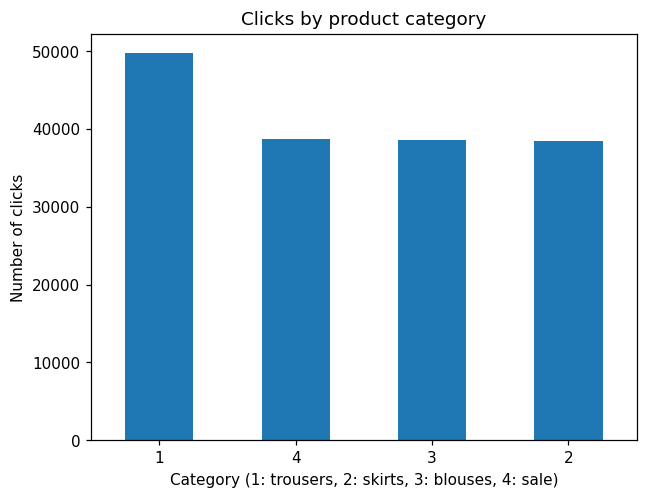

In [5]:
category_counts = df["page 1 (main category)"].value_counts()

print(category_counts.sort_index())

category_counts.plot(kind="bar")
plt.title("Clicks by product category")
plt.xlabel("Category (1: trousers, 2: skirts, 3: blouses, 4: sale)")
plt.ylabel("Number of clicks")
plt.xticks(rotation=0)
plt.show()

Category 1 (trousers) has 49,742 clicks, while each other category has about 38,000. These are current-click counts; the next-category distribution is checked after creating the target.

### 5.2 Price distribution

count    165474.000000
mean         43.802507
std          12.548131
min          18.000000
25%          33.000000
50%          43.000000
75%          52.000000
max          82.000000
Name: price, dtype: float64


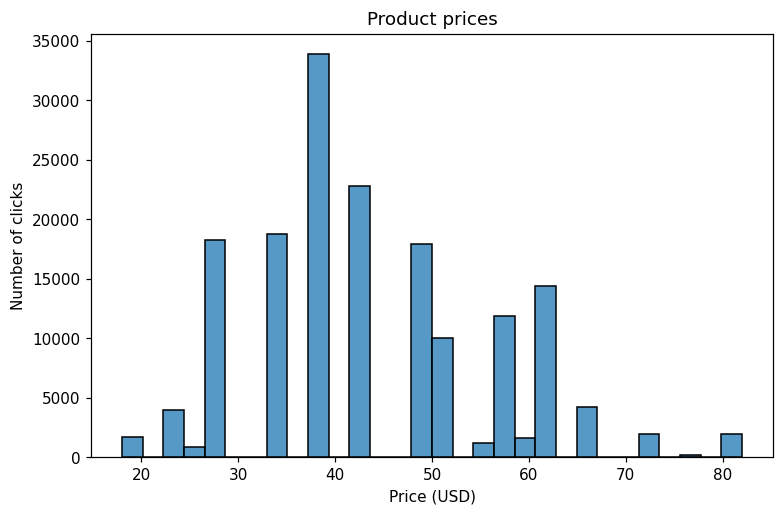

In [6]:
print(df["price"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30)
plt.title("Product prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of clicks")
plt.show()

Prices range from $18 to $82, with a median of $43. Price remains a current-click feature, but this chart does not establish its predictive value.

### 5.3 Price by current category

page 1 (main category)
1    43.0
2    52.0
3    43.0
4    38.0
Name: price, dtype: float64


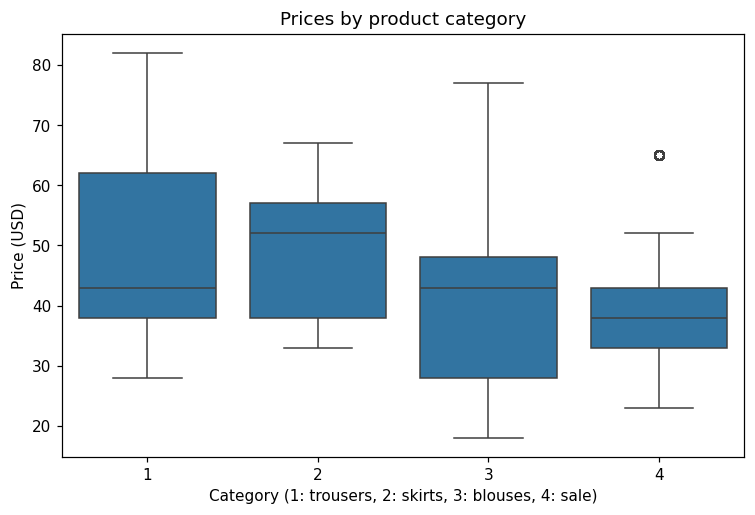

In [7]:
print(df.groupby("page 1 (main category)")["price"].median())

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="page 1 (main category)",
    y="price"
)
plt.title("Prices by product category")
plt.xlabel("Category (1: trousers, 2: skirts, 3: blouses, 4: sale)")
plt.ylabel("Price (USD)")
plt.show()

Median prices are $43 for trousers, $52 for skirts, $43 for blouses, and $38 for sale. This variation gives context for comparing prices within categories.

### 5.4 Country codes

Country codes describe IP origins, not exact user locations: 12 means unidentified, and 43–47 are domain types. Show the eight most clicked groups and combine the rest as Other, with separate click and session percentages.

,Clicks,Sessions,Click %,Session %
country,,,,
Poland,133963,19582,80.96,81.50
Czech Republic,18003,2261,10.88,9.41
Lithuania,4091,527,2.47,2.19
net (*.net),2522,681,1.52,2.83
com (*.com),1385,240,0.84,1.00
Germany,834,101,0.50,0.42
Ireland,811,102,0.49,0.42
Slovakia,716,88,0.43,0.37
Other,3149,444,1.90,1.85


All sessions have one country code.
Unidentified clicks: 210
Domain-type clicks (codes 43 to 47): 3951


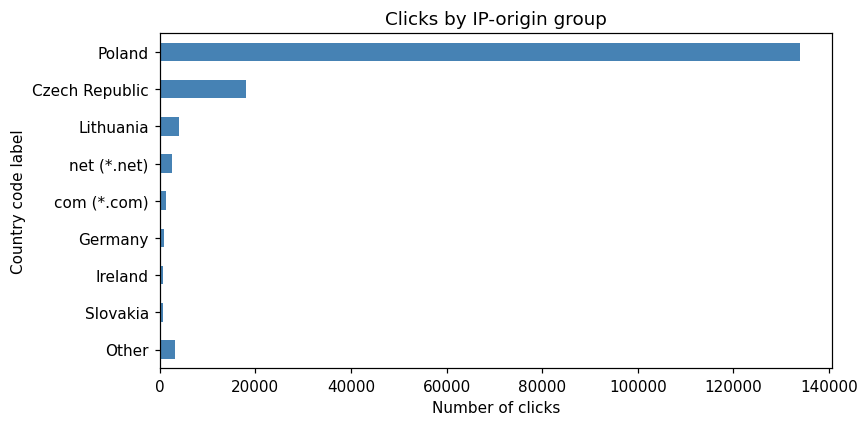

In [8]:
country_names = dict(enumerate([
    "Australia", "Austria", "Belgium", "British Virgin Islands", "Cayman Islands",
    "Christmas Island", "Croatia", "Cyprus", "Czech Republic", "Denmark", "Estonia",
    "unidentified", "Faroe Islands", "Finland", "France", "Germany", "Greece",
    "Hungary", "Iceland", "India", "Ireland", "Italy", "Latvia", "Lithuania",
    "Luxembourg", "Mexico", "Netherlands", "Norway", "Poland", "Portugal", "Romania",
    "Russia", "San Marino", "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland",
    "Ukraine", "United Arab Emirates", "United Kingdom", "USA", "biz (*.biz)",
    "com (*.com)", "int (*.int)", "net (*.net)", "org (*.org)"
], start=1))

country_labels = df["country"].map(country_names)
assert country_labels.notna().all()
assert df.groupby("session ID")["country"].nunique().eq(1).all()

top_countries = country_labels.value_counts().head(8).index
country_groups = country_labels.where(country_labels.isin(top_countries), "Other")
country_table = pd.DataFrame({
    "Clicks": country_groups.value_counts(),
    "Sessions": df.groupby(country_groups)["session ID"].nunique()
}).reindex([*top_countries, "Other"])
country_table["Click %"] = (100 * country_table["Clicks"] / len(df)).round(2)
country_table["Session %"] = (
    100 * country_table["Sessions"] / df["session ID"].nunique()
).round(2)

display(country_table)
print("All sessions have one country code.")
print("Unidentified clicks:", int(df["country"].eq(12).sum()))
print("Domain-type clicks (codes 43 to 47):", int(df["country"].between(43, 47).sum()))

ax = country_table["Clicks"].plot.barh(figsize=(8, 4), color="steelblue")
ax.invert_yaxis()
ax.set(
    title="Clicks by IP-origin group",
    xlabel="Number of clicks",
    ylabel="Country code label"
)
plt.tight_layout()
plt.show()

Poland accounts for 133,963 clicks (80.96%) and 19,582 sessions (81.50%), so results may not represent less common IP-origin groups equally well. Other contains 3,149 clicks (1.90%); across all groups, 210 clicks are unidentified and 3,951 use domain-type codes.

### 5.5 Product colours

Use the 14 colour names from the description; the striped bar represents "of many colors".

,Clicks,Click %
colour,,
black,29764,17.99
blue,29259,17.68
gray,17476,10.56
brown,16517,9.98
white,15939,9.63
of many colors,13531,8.18
red,8830,5.34
beige,7785,4.70
green,6876,4.16


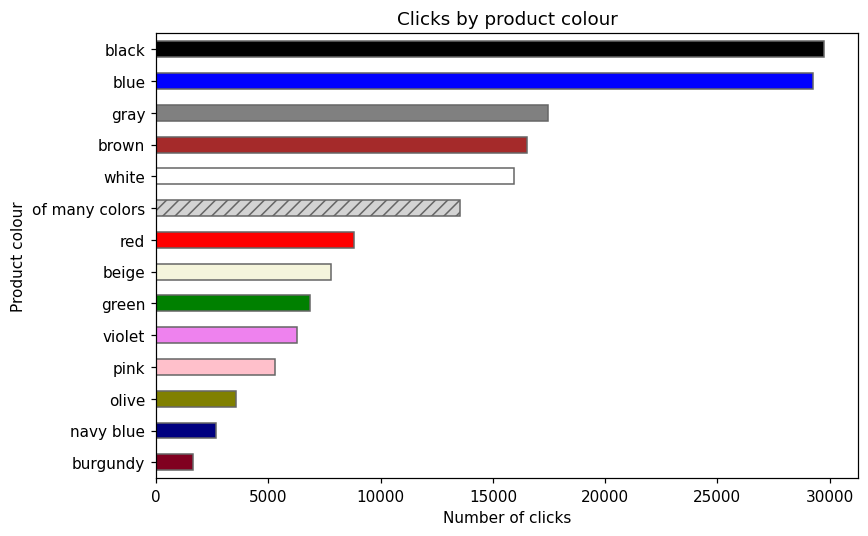

In [9]:
colour_names = dict(enumerate([
    "beige", "black", "blue", "brown", "burgundy", "gray", "green", "navy blue",
    "of many colors", "olive", "pink", "red", "violet", "white"
], start=1))

colour_counts = df["colour"].map(colour_names).value_counts()
colour_table = colour_counts.rename("Clicks").to_frame()
colour_table["Click %"] = (100 * colour_counts / len(df)).round(2)

display(colour_table)

bar_colours = {name: name for name in colour_names.values()}
bar_colours.update({
    "burgundy": "#800020",
    "navy blue": "navy",
    "of many colors": "lightgray"
})
ax = colour_counts.plot.barh(
    figsize=(8, 5),
    color=[bar_colours[c] for c in colour_counts.index],
    edgecolor="#666666"
)
ax.patches[list(colour_counts.index).index("of many colors")].set_hatch("///")
ax.invert_yaxis()
ax.set(
    title="Clicks by product colour",
    xlabel="Number of clicks",
    ylabel="Product colour"
)
plt.tight_layout()
plt.show()

Black leads with 29,764 clicks (17.99%), closely followed by blue with 29,259 (17.68%). Burgundy is least common with 1,667 (1.01%). Colour describes the current product and may reflect its category mix; these counts alone do not link colour to the next category.

### 5.6 Photo location

Location is the photo's position on the page, not a country or address.

In [10]:
location_names = dict(enumerate([
    "top left", "top middle", "top right",
    "bottom left", "bottom middle", "bottom right"
], start=1))

location_counts = (
    df["location"].map(location_names).value_counts().reindex(location_names.values())
)
location_table = location_counts.rename("Clicks").to_frame()
location_table["Click %"] = (100 * location_counts / len(df)).round(2)

display(location_table)

,Clicks,Click %
location,,
top left,34532,20.87
top middle,33383,20.17
top right,21656,13.09
bottom left,27377,16.54
bottom middle,27783,16.79
bottom right,20743,12.54


Top left has the most clicks: 34,532 (20.87%). The three top positions together account for 54.13% of clicks. Page position may describe browsing context, but these counts cannot separate placement from which products were shown there.

### 5.7 Model photography

Code 1 is a front view (en face); code 2 is a side view (profile).

In [11]:
photography_names = {1: "Front view", 2: "Side view"}

photography_counts = df["model photography"].map(photography_names).value_counts()
photography_table = photography_counts.rename("Clicks").to_frame()
photography_table["Click %"] = (100 * photography_counts / len(df)).round(2)

display(photography_table)

,Clicks,Click %
model photography,,
Front view,122439,73.99
Side view,43035,26.01


Front-view photos receive 122,439 clicks (73.99%), compared with 43,035 (26.01%) for side views. Without counts of how often each view was shown, this difference does not establish a preference.

### 5.8 Relative price groups

Price 2 is a supplied flag, not a USD amount: 1 means above the product category average, and 2 means not above it. The second table shows percentages within each current category, with n giving its click count.

In [12]:
category_names = {1: "Trousers", 2: "Skirts", 3: "Blouses", 4: "Sale"}
price_group_names = {1: "Above category average", 2: "Not above category average"}

price_groups = df["price 2"].map(price_group_names)
price_group_counts = price_groups.value_counts().reindex(price_group_names.values())

print("Price groups across all clicks")
display(pd.DataFrame({
    "Clicks": price_group_counts,
    "Click %": (100 * price_group_counts / len(df)).round(2)
}))

price_by_category = pd.crosstab(
    df["page 1 (main category)"].map(category_names),
    price_groups
)
price_by_category = price_by_category.reindex(
    index=category_names.values(),
    columns=price_group_names.values()
)
price_category_rates = (
    price_by_category.div(price_by_category.sum(axis=1), axis=0).mul(100).round(2)
)
price_category_rates.columns = [c + " (%)" for c in price_category_rates.columns]
price_category_rates.insert(0, "n", price_by_category.sum(axis=1))

print("Price groups within each current category (n = clicks)")
display(price_category_rates)

Price groups across all clicks


,Clicks,Click %
price 2,,
Above category average,84695,51.18
Not above category average,80779,48.82


Price groups within each current category (n = clicks)


,n,Above category average (%),Not above category average (%)
page 1 (main category),,,
Trousers,49742,34.20,65.80
Skirts,38408,64.22,35.78
Blouses,38577,57.09,42.91
Sale,38747,54.19,45.81


Above-average products account for 84,695 clicks (51.18%). This share is 64.22% for skirts but 34.20% for trousers. The flag is fairly balanced overall, yet its mix differs by current category, so a next-category association could partly reflect the current category.

### 5.9 Month, page, and order

Month and day record the calendar date, page is the store page number (1–5), and order is a click's position within its session. Tables count clicks, so longer sessions contribute more rows.

In [13]:
month_names = {4: "April", 5: "May", 6: "June", 7: "July", 8: "August"}

for column, names in [
    ("month", month_names),
    ("page", {i: f"Page {i}" for i in range(1, 6)})
]:
    counts = df[column].map(names).value_counts().reindex(names.values())

    print(f"{column.capitalize()} distribution (clicks)")
    display(pd.DataFrame({
        "Clicks": counts,
        "Click %": (100 * counts / len(df)).round(2)
    }))

dates = pd.to_datetime(df[["year", "month", "day"]])

print("Recorded dates:", dates.min().date(), "to", dates.max().date())
print("Distinct recorded days:", dates.nunique())

print("Click order within a session: summary across clicks")
display(
    df["order"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("Click order")
)
print("Clicks after order 20:", int(df["order"].gt(20).sum()))

Month distribution (clicks)


,Clicks,Click %
month,,
April,48199,29.13
May,35654,21.55
June,32242,19.48
July,35231,21.29
August,14148,8.55


Page distribution (clicks)


,Clicks,Click %
page,,
Page 1,93452,56.48
Page 2,41037,24.80
Page 3,19301,11.66
Page 4,8861,5.35
Page 5,2823,1.71


Recorded dates: 2008-04-01 to 2008-08-13
Distinct recorded days: 135
Click order within a session: summary across clicks


,Click order
count,165474.000000
mean,9.817476
std,13.478411
min,1.000000
50%,6.000000
90%,23.000000
95%,32.000000
99%,66.000000
max,195.000000


Clicks after order 20: 19372


April has 48,199 clicks (29.13%) and August has 14,148 (8.55%); the 135 recorded days run from April 1 to August 13, 2008, so incomplete August cannot establish a monthly trend. Store page 1 accounts for 56.48% of clicks, while click order has a median of 6, a 95th percentile of 32, and a maximum of 195. Only 19,372 clicks (11.71%) occur after order 20; later clicks are less common but offer more browsing history.

### 5.10 Product codes

Page 2 identifies the product, while page 1 identifies its main category; show only the eight most clicked products.

In [14]:
product_counts = df["page 2 (clothing model)"].value_counts()

print("Unique products:", product_counts.size)
display(pd.DataFrame({
    "Clicks": product_counts.head(8),
    "Click %": (100 * product_counts.head(8) / len(df)).round(2)
}))
print(
    "Click share of the top eight products (%):",
    round(100 * product_counts.head(8).sum() / len(df), 2)
)

Unique products: 217


,Clicks,Click %
page 2 (clothing model),,
B4,3579,2.16
A2,3013,1.82
A11,2789,1.69
P1,2681,1.62
B10,2566,1.55
A4,2522,1.52
A15,2489,1.50
A5,2354,1.42


Click share of the top eight products (%): 13.29


There are 217 product codes, led by B4 with 3,579 clicks (2.16%). The top eight account for 13.29% of clicks, so activity is spread across many products and less common codes offer fewer examples for next-category comparisons.

## 6. Sort clicks

Sort by session ID and order so history follows the click sequence within each session.

In [15]:
df = df.sort_values(["session ID", "order"]).reset_index(drop=True)

assert df["session ID"].is_monotonic_increasing
assert df.groupby("session ID")["order"].diff().dropna().gt(0).all()
print("Clicks are sorted correctly within each session.")

df[["session ID", "order", "page 1 (main category)"]].head(15)

Clicks are sorted correctly within each session.


,session ID,order,page 1 (main category)
0,1,1,1
1,1,2,1
2,1,3,2
3,1,4,2
4,1,5,2
5,1,6,3
6,1,7,3
7,1,8,4
8,1,9,4
9,2,1,2


The order checks pass, and the preview shows that click order restarts for session 2. We can now create history within each session without carrying values from one session into another.

## 7. Create features from earlier clicks

### 7.1 Previous click features

In [16]:
df["prev_category"] = df.groupby("session ID")["page 1 (main category)"].shift(1)
df["prev_product"] = df.groupby("session ID")["page 2 (clothing model)"].shift(1)
df["prev_location"] = df.groupby("session ID")["location"].shift(1)

df["same_category_prev"] = (
    df["page 1 (main category)"] == df["prev_category"]
).astype(int)
df["same_product_prev"] = (
    df["page 2 (clothing model)"] == df["prev_product"]
).astype(int)

df[[
    "session ID", "order", "prev_category", "prev_product", "prev_location",
    "same_category_prev", "same_product_prev"
]].head(6)

,session ID,order,prev_category,prev_product,prev_location,same_category_prev,same_product_prev
0,1,1,NaN,NaN,NaN,0,0
1,1,2,1.0,A13,5.0,1,0
2,1,3,1.0,A16,6.0,0,0
3,1,4,2.0,B4,2.0,1,0
4,1,5,2.0,B17,6.0,1,0
5,1,6,2.0,B8,3.0,0,0


In session 1, click 3 moves from category 1 to category 2, so same_category_prev is 0. The first click has no previous values.

### 7.2 Price history features

In [17]:
df["prev_price"] = df.groupby("session ID")["price"].shift(1)
df["price_change"] = df["price"] - df["prev_price"]
df["avg_prev_price"] = (
    df.groupby("session ID")["price"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

df[[
    "session ID", "order", "price", "prev_price", "price_change", "avg_prev_price"
]].head(6)

,session ID,order,price,prev_price,price_change,avg_prev_price
0,1,1,28,NaN,NaN,NaN
1,1,2,33,28.0,5.0,28.000000
2,1,3,52,33.0,19.0,30.500000
3,1,4,38,52.0,-14.0,37.666667
4,1,5,52,38.0,14.0,37.750000
5,1,6,57,52.0,5.0,40.600000


In session 1, the first two prices are $28 and $33; at click 2, price_change is $5 and avg_prev_price is $28. The earlier average excludes the current $33 price.

### 7.3 Session behavior features

In [18]:
df["previous_clicks"] = df.groupby("session ID").cumcount()
df["category_visit_count"] = (
    df.groupby(["session ID", "page 1 (main category)"]).cumcount()
)
df["product_visit_count"] = (
    df.groupby(["session ID", "page 2 (clothing model)"]).cumcount()
)

df[[
    "session ID", "order", "page 2 (clothing model)", "previous_clicks",
    "category_visit_count", "product_visit_count"
]].head(15)

,session ID,order,page 2 (clothing model),previous_clicks,category_visit_count,product_visit_count
0,1,1,A13,0,0,0
1,1,2,A16,1,1,0
2,1,3,B4,2,0,0
3,1,4,B17,3,1,0
4,1,5,B8,4,2,0
5,1,6,C56,5,0,0
6,1,7,C57,6,1,0
7,1,8,P67,7,0,0
8,1,9,P82,8,1,0
9,2,1,B31,0,0,0


In session 2, product A10 appears at clicks 5 and 6, with earlier visit counts of 0 and 1. The count excludes the current click.

### 7.4 Check history features

Check all 11 features against earlier clicks in the same session, including first clicks with no history. Missing values appear as NaN; match flags and earlier visit counts start at 0.

In [19]:
historical_features = [
    "prev_category",
    "prev_product",
    "prev_location",
    "same_category_prev",
    "same_product_prev",
    "prev_price",
    "price_change",
    "avg_prev_price",
    "previous_clicks",
    "category_visit_count",
    "product_visit_count"
]

sessions = df.groupby("session ID")
expected = sessions[[
    "page 1 (main category)", "page 2 (clothing model)", "location", "price"
]].shift(1)
expected.columns = ["prev_category", "prev_product", "prev_location", "prev_price"]

expected["same_category_prev"] = (
    df["page 1 (main category)"] == expected["prev_category"]
).astype(int)
expected["same_product_prev"] = (
    df["page 2 (clothing model)"] == expected["prev_product"]
).astype(int)
expected["price_change"] = df["price"] - expected["prev_price"]

# Rank starts at 1; subtract 1 to count only earlier visits.
expected["previous_clicks"] = sessions["order"].rank(method="first") - 1
expected["category_visit_count"] = (
    df.groupby(["session ID", "page 1 (main category)"])["order"]
    .rank(method="first") - 1
)
expected["product_visit_count"] = (
    df.groupby(["session ID", "page 2 (clothing model)"])["order"]
    .rank(method="first") - 1
)

# Check the earlier mean with a separate calculation that excludes this click.
previous_price_total = sessions["price"].cumsum() - df["price"]
expected["avg_prev_price"] = (
    previous_price_total / expected["previous_clicks"].replace(0, np.nan)
)

pd.testing.assert_frame_equal(
    df[historical_features], expected[historical_features], check_dtype=False
)
print("All 11 history features passed the checks. No later clicks are used.")

first_clicks = df.loc[~df.duplicated("session ID"), historical_features]

print("Missing values for each feature at the first click:")
print(first_clicks.isna().sum())
first_clicks.head()

All 11 history features passed the checks. No later clicks are used.
Missing values for each feature at the first click:
prev_category           24026
prev_product            24026
prev_location           24026
same_category_prev          0
same_product_prev           0
prev_price              24026
price_change            24026
avg_prev_price          24026
previous_clicks             0
category_visit_count        0
product_visit_count         0
dtype: int64


,prev_category,prev_product,prev_location,same_category_prev,same_product_prev,prev_price,price_change,avg_prev_price,previous_clicks,category_visit_count,product_visit_count
0,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,0,0
9,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,0,0
19,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,0,0
25,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,0,0
29,NaN,NaN,NaN,0,0,NaN,NaN,NaN,0,0,0


All 11 history features pass the checks. The six previous-value and price-history fields are missing at the first click of all 24,026 sessions, as expected; keep these missing values for model preparation.

### 7.5 Numeric feature correlations

Use Pearson correlation (a measure of straight-line association) for prices, click order, and earlier visit counts; exclude category codes because their numbers are labels, not measured amounts. Rows missing a previous price are excluded only from this calculation, which describes relationships between inputs, not prediction quality.

Complete rows used: 141448 of 165474
Order equals previous clicks + 1: True


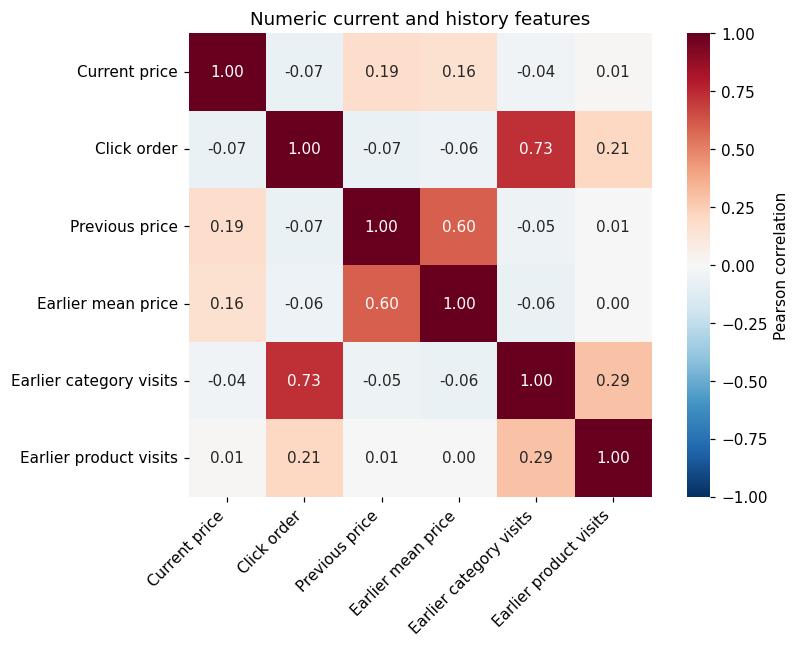

In [20]:
numeric_columns = [
    "price", "order", "prev_price", "avg_prev_price",
    "category_visit_count", "product_visit_count"
]
numeric_labels = [
    "Current price", "Click order", "Previous price", "Earlier mean price",
    "Earlier category visits", "Earlier product visits"
]

correlation_data = df[numeric_columns].dropna()
numeric_correlation = correlation_data.corr(method="pearson")

print("Complete rows used:", len(correlation_data), "of", len(df))
print(
    "Order equals previous clicks + 1:",
    df["order"].eq(df["previous_clicks"] + 1).all()
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_correlation,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    square=True,
    xticklabels=numeric_labels,
    yticklabels=numeric_labels,
    cbar_kws={"label": "Pearson correlation"}
)
plt.title("Numeric current and history features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The matrix uses 141,448 of 165,474 rows: current and previous prices have correlation 0.19, while previous price and earlier mean price have correlation 0.60. Click order and earlier category visits have correlation 0.73, partly because later clicks allow more prior visits. Previous clicks equals order minus 1 throughout, so including both would duplicate information.

## 8. Create the next-category target

### 8.1 Create and check next_category

In [21]:
df["next_category"] = df.groupby("session ID")["page 1 (main category)"].shift(-1)

same_session_next = df["session ID"].eq(df["session ID"].shift(-1))
expected_target = df["page 1 (main category)"].shift(-1).where(same_session_next)
pd.testing.assert_series_equal(df["next_category"], expected_target, check_names=False)
print(
    "The target matches the next click. The last click in each session has no target."
)

df = df.dropna(subset=["next_category"]).copy()

print("Rows with a target:", len(df))
print("Rows with a missing target:", df["next_category"].isna().sum())

df[
    [
        "session ID",
        "order",
        "page 1 (main category)",
        "next_category"
    ]
].head(15)

The target matches the next click. The last click in each session has no target.
Rows with a target: 141448
Rows with a missing target: 0


,session ID,order,page 1 (main category),next_category
0,1,1,1,1.0
1,1,2,1,2.0
2,1,3,2,2.0
3,1,4,2,2.0
4,1,5,2,3.0
5,1,6,3,3.0
6,1,7,3,4.0
7,1,8,4,4.0
9,2,1,2,2.0
10,2,2,2,2.0


Creating the target leaves 141,448 labeled clicks in 18,984 sessions. Each session loses its last click because no next category is recorded. Sessions with only one click disappear, so the later model evaluation covers clicks with an observed next click.

### 8.2 Target distribution

               Clicks  Percent
next_category                 
1.0             40495    28.63
2.0             31936    22.58
3.0             34132    24.13
4.0             34885    24.66


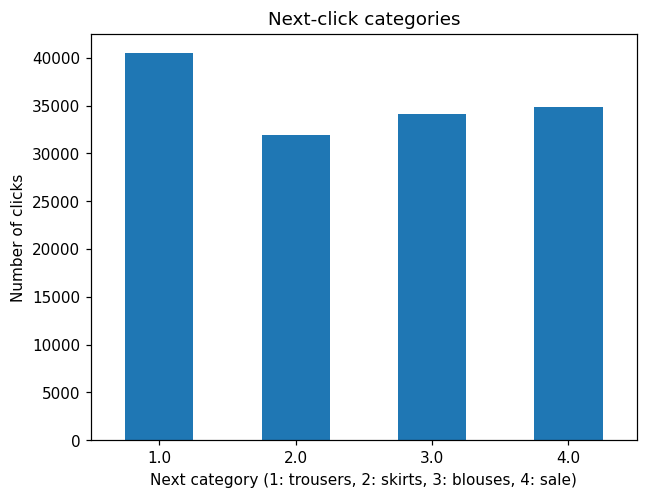

In [22]:
target_counts = df["next_category"].value_counts().sort_index()
target_summary = pd.DataFrame({
    "Clicks": target_counts,
    "Percent": (target_counts / len(df) * 100).round(2)
})

print(target_summary)

target_counts.plot(kind="bar")
plt.title("Next-click categories")
plt.xlabel("Next category (1: trousers, 2: skirts, 3: blouses, 4: sale)")
plt.ylabel("Number of clicks")
plt.xticks(rotation=0)
plt.show()

Category 1 is the largest target group (28.63%), and category 2 is the smallest (22.58%). All four groups have substantial counts; no group dominates the data. We will use Macro F1 to give each category equal weight, with Accuracy and Weighted F1 as additional measures.

### 8.3 Next category by current category

Percentages are calculated within each row and sum to 100%; n counts labeled clicks, not independent users. These summaries cover all labeled data before the session split and are not test-set results.

In [23]:
transition_counts = pd.crosstab(df["page 1 (main category)"], df["next_category"])
transition_rates = transition_counts.div(transition_counts.sum(axis=1), axis=0).mul(100)
transition_table = transition_rates.round(2).rename(
    index=category_names,
    columns=category_names
)
transition_table.columns = [
    "Next " + c.lower() + " (%)" for c in transition_table.columns
]
transition_table.insert(0, "n", transition_counts.sum(axis=1).to_numpy())

display(transition_table)
print(
    "Same current and next category (%):",
    round(100 * df["page 1 (main category)"].eq(df["next_category"]).mean(), 2)
)

,n,Next trousers (%),Next skirts (%),Next blouses (%),Next sale (%)
page 1 (main category),,,,,
Trousers,43071,80.33,7.32,7.44,4.91
Skirts,32352,6.27,79.27,9.26,5.20
Blouses,33035,6.82,5.22,79.69,8.28
Sale,32990,4.90,4.29,4.86,85.95


Same current and next category (%): 81.25


The next click stays in the current category for 81.25% of labeled rows. Rates are 80.33% for trousers, 79.27% for skirts, 79.69% for blouses, and 85.95% for sale, with group sizes from 32,352 to 43,071 clicks. This strong descriptive link makes current category an important reference for later model comparisons.

### 8.4 Next category by photo view

Compare the next-category percentages within front-view and side-view clicks.

In [24]:
photo_next_counts = pd.crosstab(df["model photography"], df["next_category"])
photo_next_rates = photo_next_counts.div(photo_next_counts.sum(axis=1), axis=0).mul(100)
photo_next_table = photo_next_rates.round(2).rename(
    index=photography_names,
    columns=category_names
)
photo_next_table.columns = [
    "Next " + c.lower() + " (%)" for c in photo_next_table.columns
]
photo_next_table.insert(0, "n", photo_next_counts.sum(axis=1).to_numpy())

display(photo_next_table)

,n,Next trousers (%),Next skirts (%),Next blouses (%),Next sale (%)
model photography,,,,,
Front view,105220,31.16,24.76,23.59,20.48
Side view,36228,21.27,16.23,25.69,36.81


There are 105,220 labeled front-view clicks and 36,228 side-view clicks. The largest gap is for next sale: 20.48% after a front view versus 36.81% after a side view, a 16.32 percentage-point gap calculated from the unrounded rates. Different category and product mixes may explain this association; it shows neither causation nor proven model improvement.

## 9. Select features

Use the same two feature groups for every model comparison. Exclude year and the target from model inputs, and use session ID only for grouping and splitting.

In [25]:
current_features = [
    "month",
    "day",
    "country",
    "order",
    "page 1 (main category)",
    "page 2 (clothing model)",
    "colour",
    "location",
    "model photography",
    "price",
    "price 2",
    "page"
]

target = "next_category"

predictor_lists = {
    "Current Only": current_features,
    "Current + Historical Behavior": current_features + historical_features,
}

assert not {"year", "session ID", "next_category"}.intersection(
    predictor_lists["Current + Historical Behavior"]
)

## 10. Train/test split by session

Use 80% of sessions to train models and 20% to test them, keeping each session in one set. Store this fixed split in session_split with random_state=42 and reuse it for every model.

In [26]:
session_ids = df["session ID"].unique()
train_sessions, test_sessions = train_test_split(
    session_ids, test_size=0.2, random_state=42
)
session_split = {"train": train_sessions, "test": test_sessions}

train_df = df[df["session ID"].isin(session_split["train"])].copy()
test_df = df[df["session ID"].isin(session_split["test"])].copy()

overlap = set(train_df["session ID"]) & set(test_df["session ID"])
assert not overlap, "A session appears in both train and test"

print("Training rows / sessions:", len(train_df), train_df["session ID"].nunique())
print("Test rows / sessions:", len(test_df), test_df["session ID"].nunique())
print("Sessions in both sets:", len(overlap))

Training rows / sessions: 112491 15187
Test rows / sessions: 28957 3797
Sessions in both sets: 0


The split has 15,187 training sessions and 3,797 test sessions, with no shared sessions. The row counts need not follow exactly 80/20 because sessions have different lengths. Keep this split for all experiments and learn data preparation settings from the training set only.

## 11. Export train and test datasets

In [27]:
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Training data saved (rows, columns):", train_df.shape)
print("Test data saved (rows, columns):", test_df.shape)

Training data saved (rows, columns): (112491, 26)
Test data saved (rows, columns): (28957, 26)


## 12. Prepare data for machine learning

**Status: Guidance only; not implemented.** Phương Anh owns this section; Phương Linh reuses its agreed choices. Complete sections 1–11 first and keep their code, saved outputs, session split, and row order unchanged.

**Working terms**

- A pipeline keeps preparation and model fitting together so the same steps apply at prediction time.
- Data leakage means using information that would not be available when predicting, including learning preparation settings from held-out rows.
- Grouped validation keeps complete sessions together while choosing model settings using training data only.

Sections 5 and 8 already describe the full dataset, including the later test rows. Disclose this exploratory use; do not use test scores to select features, model settings, or the final model.

### 12.1 Feature types and shared inputs

**Owner:** Phương Anh.

- **Input:** `train_df`, `test_df`, `current_features`, `historical_features`, `predictor_lists`, and `target` from sections 9–11.
- **Task:** Define categorical, numerical, and binary columns for each feature group. Treat country, product/category codes, colour, location, photography, price 2, and previous category/product/location as categories. Document the treatment of month, day, and page; use the same treatment in every experiment.
- **Output:** Explicit column lists; X_train/X_test for E1 and E4; integer y_train/y_test in the original category codes 1–4.
- **Check:** Every selected feature appears exactly once; exclude year, session ID, and next_category from X. Keep 112,491 training rows and 28,957 test rows with zero shared sessions and matching X/y indices; retain first clicks with missing history.

In [ ]:
# TODO: Write the implementation described above.

### 12.2 Shared preparation

**Owner:** Phương Anh.

- **Input:** The feature lists and training/test inputs from 12.1.
- **Task:** Build unfitted ColumnTransformer/Pipeline templates. Use a consistent no-history category for missing previous codes, a documented numerical imputation rule, and OneHotEncoder(handle_unknown="ignore"). Normalize categorical types consistently before encoding. Scale numerical inputs for logistic regression; document the tree-model policy. Add imports such as SimpleImputer only when implementing.
- **Output:** Reusable unfitted preparation templates for E1 and E4, with a documented policy that also applies to E2/E3.
- **Check:** Fit imputers, encoders, and scalers on training rows only, and inside each training-validation fold. Use fresh clones for independent fits. Unknown test categories must not fail; transformed inputs must have no missing or infinite values. Do not globally fill or overwrite df/train_df/test_df.

In [ ]:
# TODO: Write the implementation described above.

### 12.3 Validation and result storage

**Owner:** Phương Anh, agreed with Phương Linh.

- **Input:** The fixed outer session_split, training session IDs, and unfitted preparation templates.
- **Task:** Define shared grouped validation folds inside train_df (for example GroupKFold using session ID), a reproducible random seed, and a limited tuning budget. Agree whether each E1/E4 pair uses fixed identical settings or equal tuning budgets on identical folds. Choose settings and the final model by validation Macro F1, then evaluate the frozen choices on the existing test set.
- **Output:** Reusable fold indices plus agreed stores: fitted_models, predictions, and a results table keyed by model and feature group; record validation Macro F1, parameters, Accuracy, Macro F1, and Weighted F1.
- **Check:** No validation fold shares sessions across its two sides. Test rows are never used for tuning, early stopping, imputation, or model selection. Save predictions in test_df row order and original category codes; use the same metrics and class order 1–4 for all experiments.

In [ ]:
# TODO: Write the implementation described above.

## 13. Baseline experiments

**Status: Guidance only; not implemented.** Phương Anh implements E1 using current features only. For each model, use section 12's preparation and validation policy, store predictions/results, and add a short interpretation after the output.

### 13.0 Current-category reference rule

**Owner:** Phương Anh.

- **Input:** The current category and true next_category in the fixed test rows.
- **Task:** Predict the next category as the current category and calculate the same three metrics as the trained models. This rule needs no fitting or tuning.
- **Output:** A reference row in the results table and aligned predictions for later comparison.
- **Check:** The 81.25% share in section 8 is from all labeled rows, not the test score. Compute the actual test metrics; do not copy that percentage. Do not count the rule as one of the four required trained models.

In [ ]:
# TODO: Write the implementation described above.

### 13.1 Logistic regression

**Owner:** Phương Anh.

- **Input:** E1 current-feature inputs, section 12 templates/folds, and shared result stores.
- **Task:** Fit LogisticRegression through the agreed pipeline and validation policy. Document regularization and max_iter; check convergence after scaling numerical inputs.
- **Output:** The fitted E1 logistic regression pipeline, test predictions, parameter record, and one row of metrics.
- **Check:** Use only current_features; keep the fixed test rows and class mapping. Fit preparation within each validation fold; reserve final test evaluation for frozen settings. Reuse the same estimator policy when comparing E4.

In [ ]:
# TODO: Write the implementation described above.

### 13.2 Decision tree

**Owner:** Phương Anh.

- **Input:** E1 current-feature inputs, section 12 templates/folds, and shared result stores.
- **Task:** Fit DecisionTreeClassifier through the agreed pipeline and validation policy. Document depth/leaf controls and random_state; compare training and validation scores for overfitting.
- **Output:** The fitted E1 decision tree pipeline, test predictions, parameter record, and one row of metrics.
- **Check:** Use only current_features; keep the fixed test rows and class mapping. Fit preparation within each validation fold; reserve final test evaluation for frozen settings. Reuse the same estimator policy when comparing E4.

In [ ]:
# TODO: Write the implementation described above.

### 13.3 Random forest

**Owner:** Phương Anh.

- **Input:** E1 current-feature inputs, section 12 templates/folds, and shared result stores.
- **Task:** Fit RandomForestClassifier through the agreed pipeline and validation policy. Document the number of trees, depth/leaf controls, random_state, and runtime; keep the paired tuning budget equal.
- **Output:** The fitted E1 random forest pipeline, test predictions, parameter record, and one row of metrics.
- **Check:** Use only current_features; keep the fixed test rows and class mapping. Fit preparation within each validation fold; reserve final test evaluation for frozen settings. Reuse the same estimator policy when comparing E4.

In [ ]:
# TODO: Write the implementation described above.

### 13.4 XGBoost

**Owner:** Phương Anh.

- **Input:** E1 current-feature inputs, section 12 templates/folds, and shared result stores.
- **Task:** Fit XGBClassifier through the agreed pipeline and validation policy. Map labels 1–4 to 0–3 for fitting and map predictions back before scoring. If using early stopping, use only a session-separated training-validation subset; never the test set.
- **Output:** The fitted E1 xgboost pipeline, test predictions, parameter record, and one row of metrics.
- **Check:** Use only current_features; keep the fixed test rows and class mapping. Fit preparation within each validation fold; reserve final test evaluation for frozen settings. Reuse the same estimator policy when comparing E4.

In [ ]:
# TODO: Write the implementation described above.

## 14. Experiments with current and earlier clicks

**Status: Guidance only; not implemented.** Phương Linh implements E4 after section 12 is agreed with Phương Anh. Keep all E1 settings or its equal-budget validation policy, changing only the feature group.

### 14.1 Logistic regression

**Owner:** Phương Linh.

- **Input:** E4 inputs (current_features + historical_features), the matching E1 logistic regression specification, and shared preparation/folds/stores.
- **Task:** Fit a fresh LogisticRegression pipeline with all 11 history features and the agreed first-click handling. Document regularization and max_iter; check convergence after scaling numerical inputs.
- **Output:** The fitted E4 logistic regression pipeline, aligned test predictions, parameter record, and metrics in the same result format as E1.
- **Check:** Use the identical outer split, validation folds, class order, metrics, and model-specific preparation policy as E1. Do not drop first clicks, change targets, or rebuild history using later clicks.

In [ ]:
# TODO: Write the implementation described above.

### 14.2 Decision tree

**Owner:** Phương Linh.

- **Input:** E4 inputs (current_features + historical_features), the matching E1 decision tree specification, and shared preparation/folds/stores.
- **Task:** Fit a fresh DecisionTreeClassifier pipeline with all 11 history features and the agreed first-click handling. Document depth/leaf controls and random_state; compare training and validation scores for overfitting.
- **Output:** The fitted E4 decision tree pipeline, aligned test predictions, parameter record, and metrics in the same result format as E1.
- **Check:** Use the identical outer split, validation folds, class order, metrics, and model-specific preparation policy as E1. Do not drop first clicks, change targets, or rebuild history using later clicks.

In [ ]:
# TODO: Write the implementation described above.

### 14.3 Random forest

**Owner:** Phương Linh.

- **Input:** E4 inputs (current_features + historical_features), the matching E1 random forest specification, and shared preparation/folds/stores.
- **Task:** Fit a fresh RandomForestClassifier pipeline with all 11 history features and the agreed first-click handling. Document the number of trees, depth/leaf controls, random_state, and runtime; keep the paired tuning budget equal.
- **Output:** The fitted E4 random forest pipeline, aligned test predictions, parameter record, and metrics in the same result format as E1.
- **Check:** Use the identical outer split, validation folds, class order, metrics, and model-specific preparation policy as E1. Do not drop first clicks, change targets, or rebuild history using later clicks.

In [ ]:
# TODO: Write the implementation described above.

### 14.4 XGBoost

**Owner:** Phương Linh.

- **Input:** E4 inputs (current_features + historical_features), the matching E1 xgboost specification, and shared preparation/folds/stores.
- **Task:** Fit a fresh XGBClassifier pipeline with all 11 history features and the agreed first-click handling. Map labels 1–4 to 0–3 for fitting and map predictions back before scoring. If using early stopping, use only a session-separated training-validation subset; never the test set.
- **Output:** The fitted E4 xgboost pipeline, aligned test predictions, parameter record, and metrics in the same result format as E1.
- **Check:** Use the identical outer split, validation folds, class order, metrics, and model-specific preparation policy as E1. Do not drop first clicks, change targets, or rebuild history using later clicks.

In [ ]:
# TODO: Write the implementation described above.

## 15. Model evaluation

**Status: Guidance only; not implemented.**

### 15.1 Metrics and category errors

**Owner:** Phương Linh.

- **Input:** Saved predictions/results for four models under E1 and E4, plus the current-category rule; the unchanged y_test.
- **Task:** Assemble the eight model result rows and the reference row. Show confusion matrices for the models selected using training validation, with category names; optionally add per-category reports.
- **Output:** A comparison table containing Accuracy, Macro F1, and Weighted F1; labeled confusion matrices; a short error interpretation.
- **Check:** All rows use exactly the same test observations and category codes. Confirm matrix totals equal 28,957, use class order 1–4, and handle undefined metrics explicitly. Rank model choices using training validation rather than selecting the highest test score.

In [ ]:
# TODO: Write the implementation described above.

## 16. Current only vs current + historical behavior

**Status: Guidance only; not implemented.**

### 16.1 Paired comparison

**Owner:** Phương Linh.

- **Input:** Validated E1/E4 results for each of the four estimators and the reference rule.
- **Task:** Pair E1 with E4 by estimator and calculate E4 minus E1 for all three metrics. Show a compact table or chart and describe whether history helps consistently.
- **Output:** Four paired comparisons, gains/losses with a clear unit, and an answer tied to the research question.
- **Check:** Keep identical test rows and the agreed tuning policy; distinguish percentage points from relative percent changes. Report decreases too; a single split does not establish statistical significance.

In [ ]:
# TODO: Write the implementation described above.

## 17. Ablation study

**Status: Guidance only; not implemented.** Add one feature group at a time to measure its contribution; keep the estimator and settings fixed after selection on training validation.

### 17.1 Run E1 to E4

**Owner:** Phương Linh.

- **Input:** One estimator selected by validation Macro F1, its fixed settings, the shared split/folds, and section 12 preparation policy.
- **Task:** Define E1 = current_features; E2 = E1 + prev_category, prev_product, prev_location, same_category_prev, same_product_prev; E3 = E2 + prev_price, price_change, avg_prev_price; E4 = E3 + previous_clicks, category_visit_count, product_visit_count. Fit fresh pipelines for these four nested groups.
- **Output:** An E1–E4 table with feature lists, counts, the three metrics, and stepwise Macro F1 differences; a short interpretation.
- **Check:** Use 12, 17, 20, and 23 inputs respectively, without duplicates. E4 must match predictor_lists["Current + Historical Behavior"]. Keep first-click rows and preprocessing policy consistent. Reuse prior results only when estimator settings, split, and preparation match exactly.

In [ ]:
# TODO: Write the implementation described above.

## 18. Feature importance

**Status: Guidance only; not implemented.** Importance describes model use of a feature, not a causal effect on browsing.

### 18.1 Explain a selected model

**Owner:** Phương Linh.

- **Input:** A pipeline selected using training validation, its feature names, and held-out data for explanation.
- **Task:** Choose a method suited to the estimator: for example tree importance or permutation importance (the score change after shuffling a feature). If using encoded columns, explain how they map back to original features; if using coefficients, explain the class and scale.
- **Output:** A small ranked table/chart with the method, score, data split, and limitations; an interpretation of current versus history features.
- **Check:** Do not use test-derived importance to select features or retune models. Note that related predictors can share importance and row-wise shuffling may disrupt session patterns. Do not claim that a highly ranked feature causes a click.

In [ ]:
# TODO: Write the implementation described above.

## 19. Business interpretation

**Status: Writing task; no code required.**

### 19.1 Practical meaning

**Owner:** All members.

- **Input:** Verified comparisons, category errors, and feature-importance findings from sections 15–18.
- **Task:** Write two or three evidence-linked implications for category navigation or recommendations, stating the metric or error pattern behind each.
- **Output:** A short explanation of possible uses and the checks needed before real deployment.
- **Check:** This dataset measures clicks, not purchases, revenue, conversion, or campaign impact; do not claim those outcomes improved.

*TODO: Replace this note with your evidence-based interpretation.*

## 20. Limitations

**Status: Writing task; no code required.**

### 20.1 Scope and uncertainty

**Owner:** All members.

- **Input:** The source description, EDA coverage, split design, and actual experiment results.
- **Task:** Discuss 2008 data from one store, incomplete August, IP-origin imbalance, related clicks within sessions, excluded final/single clicks, and unseen products. Explain that random held-out sessions are not a future-period or guaranteed unseen-user test; disclose full-data EDA.
- **Output:** A focused limitations paragraph and realistic next checks such as time-based validation or additional data, without changing this project split.
- **Check:** Separate observed results from proposals. Avoid significance, causal, geographic, or business-outcome claims unsupported by these data.

*TODO: Replace this note with your evidence-based interpretation.*

## 21. Conclusion

**Status: Writing task; no code required.**

### 21.1 Answer the research question

**Owner:** All members.

- **Input:** The verified comparison, current-category rule, ablation results, and limitations.
- **Task:** State whether history improves next-category prediction in these experiments, cite exact Macro F1 changes and the reference comparison, and identify the most useful added feature group only if results support it.
- **Output:** One concise conclusion and a justified next step; no fabricated result while modeling remains incomplete.
- **Check:** Match every quoted value to a saved output. Before submission, restart the kernel and run top to bottom; resolve all TODOs, preserve the session split, and review notebook changes together.

*TODO: Replace this note with your evidence-based interpretation.*